## Factores asociados a mortalidad intrahospitalaria

1. ¿Qué de diagnóstico presentan una mayor probabilidad de ocurrir en Casa frente a Hospital o Clínica?

2. ¿Existe una correlación significativa entre los meses de invierno (junio-agosto) y un aumento en las defunciones por enfermedades del sistema respiratorio en comparación con otras causas?

3. ¿Cómo varía la edad promedio de defunción  entre hombres y mujeres a lo largo de las distintas regiones de Chile?


Reformular preguntar 1 y 3 a que sean más investigativas (pregunta 2 esta bien)

In [2]:
#importan librerias importantes
import matplotlib as plt
import pandas as pd
import numpy as np

In [3]:
#Cargar el dataset
path = "DEFUNCIONES_FUENTE_DEIS_2023_2026_04032026.csv"

df = pd.read_csv(path, encoding='latin-1', sep=';')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
display(df)


,AÑO,FECHA_DEF,SEXO_NOMBRE,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG1,CODIGO_GRUPO_DIAG1,GLOSA_GRUPO_DIAG1,CODIGO_CATEGORIA_DIAG1,GLOSA_CATEGORIA_DIAG1,CODIGO_SUBCATEGORIA_DIAG1,GLOSA_SUBCATEGORIA_DIAG1,DIAG2,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION
0,2026,2026-02-15,Hombre,1,81,13604.0,Padre Hurtado,Metropolitana de Santiago,I120,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,I12,Enfermedad renal hipertensiva,I120,ENFERMEDAD RENAL HIPERTENSIVA CON INSUFICIENCI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
1,2026,2026-01-23,Mujer,1,97,13604.0,Padre Hurtado,Metropolitana de Santiago,I678,I00-I99,Enfermedades del sistema circulatorio,I60-I69,Enfermedades cerebrovasculares,I67,Otras enfermedades cerebrovasculares,I678,OTRAS ENFERMEDADES CEREBROVASCULARES ESPECIFIC...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
2,2026,2026-01-05,Hombre,1,93,13604.0,Padre Hurtado,Metropolitana de Santiago,I10X,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,I10,Hipertensión esencial (primaria),I10X,HIPERTENSION ESENCIAL (PRIMARIA),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
3,2026,2026-02-14,Hombre,1,88,13604.0,Padre Hurtado,Metropolitana de Santiago,E119,E00-E90,"Enfermedades endocrinas, nutricionales y metab...",E10-E14,Diabetes mellitus,E11,Diabetes mellitus no insulinodependiente,E119,DIABETES MELLITUS NO INSULINODEPENDIENTE SIN M...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
4,2026,2026-01-05,Mujer,1,89,13604.0,Padre Hurtado,Metropolitana de Santiago,J449,J00-J99,Enfermedades del sistema respiratorio,J40-J47,Enfermedades crónicas de las vías respiratoria...,J44,Otras enfermedades pulmonares obstructivas cró...,J449,ENFERMEDAD PULMÓNAR OBSTRUCTIVA CRONICA NO ESP...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394971,2023,2023-11-11,Hombre,1,58,12101.0,Punta Arenas,De Magallanes y de La Antártica Chilena,I219,I00-I99,Enfermedades del sistema circulatorio,I20-I25,Enfermedades isquémicas del corazón,I21,Infarto agudo del miocardio,I219,INFARTO AGUDO DEL MIOCARDIO SIN OTRA ESPECIFIC...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Otro
394972,2023,2023-12-22,Hombre,1,20,15101.0,Arica,De Arica y Parinacota,S299,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",S20-S29,Traumatismos del tórax,S29,Otros traumatismos y los no especificados del ...,S299,TRAUMATISMO DEL TORAX NO ESPECIFICADO,X958,V01-Y98,Causas externas de morbilidad y de mortalidad,X85-Y09,Agresiones,X95,"Agresión con disparo de otras armas de fuego, ...",X958,AGRESIÓN CON DISPARO DE OTRAS ARMAS DE FUEGO Y...,Hospital o Clínica
394973,2023,2023-12-05,Hombre,1,37,13125.0,Quilicura,Metropolitana de Santiago,S396,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",S30-S39,"Traumatismos del abdomen, de la región lumbosa...",S39,Otros traumatismos y los no especificados del ...,S396,TRAUMATISMO DE ÓRGANO(S) INTRAABDOMINAL(ES) CO...,X599,V01-Y98,Causas externas de morbilidad y de mortalidad,X58-X59,Exposición accidental a otros factores y a los...,X59,Exposición a factores no especificados,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,Otro
394974,2023,2023-07-31,Hombre,1,31,8101.0,Concepción,Del Bíobío,S199,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",S10-S19,Traumatismos del cuello,S19,Otros traumatismos y los no especificados del ...,S199,TRAUMATISMO DEL CUELLO NO ESPECIFICADO,X999,V01-Y98,Causas externas de morbilidad y de mortalidad,X85-Y09,Agresiones,X99,Agresión con objeto cortante,X999,AGRESIÓN CON OBJETO CORTANTE OCURRIDA EN UN LU...,Otro


In [4]:
# Clasificación corregida de las variables principales
clasificacion_df = pd.DataFrame({
    'Variable': [
        'AÑO', 
        'FECHA_DEF', 
        'SEXO_NOMBRE', 
        'EDAD_CANT', 
        'COMUNA', 
        'GLOSA_CAPITULO_DIAG1'
    ],
    'Tipo': [
        'Cualitativa', 
        'Cuantitativa', 
        'Cualitativa', 
        'Cuantitativa', 
        'Cualitativa', 
        'Cualitativa'
    ],
    'Subtipo': [
        'Ordinal',     # El año tiene un orden lógico temporal
        'Continua',    # Las fechas se tratan como una escala continua de tiempo
        'Nominal',     # Categorías sin orden (Hombre/Mujer)
        'Discreta',    # Años cumplidos (valores enteros)
        'Nominal',     # Nombres de comunas
        'Nominal'      # Categorías de enfermedades
    ],
    'Justificación': [
        'Indica el periodo temporal con un orden cronológico.',
        'Representa un punto específico en la línea de tiempo.',
        'Categoría biológica sin jerarquía inherente.',
        'Conteo de años transcurridos desde el nacimiento.',
        'Ubicación geográfica administrativa.',
        'Nombre de la causa principal de muerte según la CIE-10.'
    ]
})

display(clasificacion_df)

,Variable,Tipo,Subtipo,Justificación
0,AÑO,Cualitativa,Ordinal,Indica el periodo temporal con un orden cronol...
1,FECHA_DEF,Cuantitativa,Continua,Representa un punto específico en la línea de ...
2,SEXO_NOMBRE,Cualitativa,Nominal,Categoría biológica sin jerarquía inherente.
3,EDAD_CANT,Cuantitativa,Discreta,Conteo de años transcurridos desde el nacimiento.
4,COMUNA,Cualitativa,Nominal,Ubicación geográfica administrativa.
5,GLOSA_CAPITULO_DIAG1,Cualitativa,Nominal,Nombre de la causa principal de muerte según l...


In [4]:
#Dividir el dataset en 4 distintos (separados por año)
df2023 = df[df["AÑO"] == 2023]
df2024 = df[df["AÑO"] == 2024]
df2025 = df[df["AÑO"] == 2025]
df2026 = df[df["AÑO"] == 2026]

#Sacamos cuantos pacientes hay en cada año
pacientes2023 = df2023.shape[0]
pacientes2024 = df2024.shape[0]
pacientes2025 = df2025.shape[0]
pacientes2026 = df2026.shape[0]

print(f'Pacientes en el año 2023: {pacientes2023}')
print(f'Pacientes en el año 2024: {pacientes2024}')
print(f'Pacientes en el año 2025: {pacientes2025}')
print(f'Pacientes en el año 2026: {pacientes2026}')


Pacientes en el año 2023: 122218
Pacientes en el año 2024: 126934
Pacientes en el año 2025: 126454
Pacientes en el año 2026: 19370


In [5]:
años = [2023, 2024, 2025, 2026]
resumen = []

for año in años:

    dfAño = df[df["AÑO"] == año]
    print(f"\n=== ANÁLISIS DESCRIPTIVO AÑO {año} ===")
    
    mediaEdad = dfAño['EDAD_CANT'].mean()
    medianaEdad = dfAño['EDAD_CANT'].median()
    desvEdad = dfAño['EDAD_CANT'].std()
    cantpersonas = dfAño.shape[0]
    print(f"Edad - Media: {mediaEdad:.2f}, Mediana: {medianaEdad:.2f}, Desv. Estándar: {desvEdad:.2f}, Cantidad de personas: {cantpersonas}")

    frecSexo = dfAño['SEXO_NOMBRE'].value_counts()
    print("\nDistribución por Sexo:")
    print(frecSexo)

    topCausas = dfAño['GLOSA_CAPITULO_DIAG1'].value_counts().head(5)
    print("\nTop 5 Causas de Muerte (Capítulos):")
    print(topCausas)
    
    resumen.append({
        'Año': año,
        'Total Defunciones': len(dfAño),
        'Edad Promedio': round(mediaEdad, 2),
        'Causa Principal': topCausas.index[0]
    })

# Crear un DataFrame resumen para comparar los años fácilmente
df_resumen_final = pd.DataFrame(resumen)
print("\nRESUMEN COMPARATIVO FINAL")
display(df_resumen_final)


=== ANÁLISIS DESCRIPTIVO AÑO 2023 ===
Edad - Media: 72.88, Mediana: 77.00, Desv. Estándar: 18.33, Cantidad de personas: 122218

Distribución por Sexo:
SEXO_NOMBRE
Hombre           63711
Mujer            58495
Indeterminado       12
Name: count, dtype: int64

Top 5 Causas de Muerte (Capítulos):
GLOSA_CAPITULO_DIAG1
Enfermedades del sistema circulatorio                                             31149
Tumores [Neoplasias]                                                              30796
Enfermedades del sistema respiratorio                                             13728
Enfermedades del sistema digestivo                                                 8901
Traumatismos, envenenamientos y algunas otras consecuencias de causas externas     8279
Name: count, dtype: int64

=== ANÁLISIS DESCRIPTIVO AÑO 2024 ===
Edad - Media: 73.37, Mediana: 77.00, Desv. Estándar: 17.98, Cantidad de personas: 126934

Distribución por Sexo:
SEXO_NOMBRE
Hombre           65840
Mujer            61091
Indeter

,Año,Total Defunciones,Edad Promedio,Causa Principal
0,2023,122218,72.88,Enfermedades del sistema circulatorio
1,2024,126934,73.37,Enfermedades del sistema circulatorio
2,2025,126454,73.55,Enfermedades del sistema circulatorio
3,2026,19370,73.22,Tumores [Neoplasias]


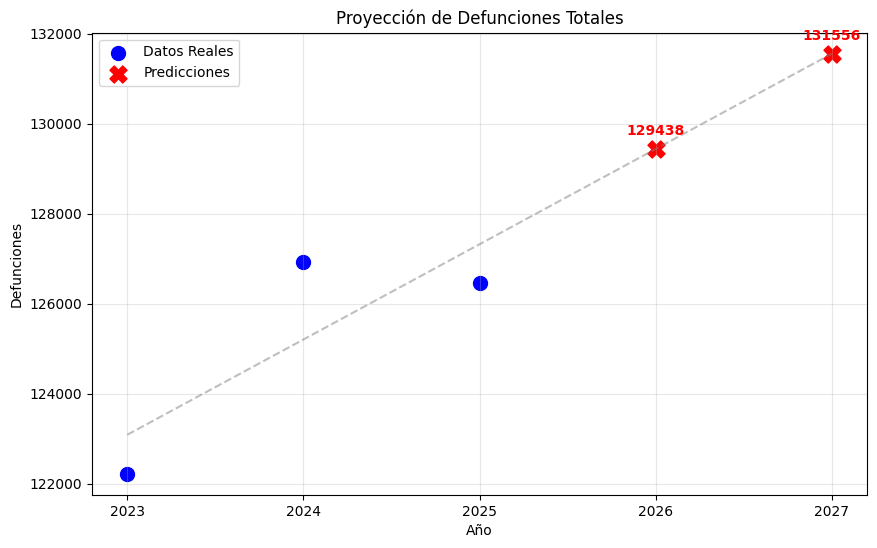

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Datos históricos
anos_reales = np.array([2023, 2024, 2025]).reshape(-1, 1)
totales_reales = np.array([122218, 126934, 126454])

# 2. Modelo
modelo = LinearRegression()
modelo.fit(anos_reales, totales_reales)

# 3. Predicciones
anos_pred = np.array([2026, 2027]).reshape(-1, 1)
totales_pred = modelo.predict(anos_pred)

# 4. Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(anos_reales, totales_reales, color='blue', s=100, label='Datos Reales')
plt.scatter(anos_pred, totales_pred, color='red', marker='X', s=150, label='Predicciones')

# Línea de tendencia
anos_linea = np.array([2023, 2024, 2025, 2026, 2027]).reshape(-1, 1)
plt.plot(anos_linea, modelo.predict(anos_linea), color='gray', linestyle='--', alpha=0.5)

for i in range(len(anos_pred)):
    valor_x = anos_pred[i][0]    
    valor_y = totales_pred[i]
    plt.annotate(f"{int(valor_y)}", (valor_x, valor_y), 
                 textcoords="offset points", xytext=(0,10), ha='center', 
                 color='red', weight='bold')

plt.title('Proyección de Defunciones Totales')
plt.xlabel('Año')
plt.ylabel('Defunciones')
plt.xticks([2023, 2024, 2025, 2026, 2027])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
dfHospital = df[df["LUGAR_DEFUNCION"] == "Hospital o Clínica"]
dfHospital

,AÑO,FECHA_DEF,SEXO_NOMBRE,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG1,CODIGO_GRUPO_DIAG1,GLOSA_GRUPO_DIAG1,CODIGO_CATEGORIA_DIAG1,GLOSA_CATEGORIA_DIAG1,CODIGO_SUBCATEGORIA_DIAG1,GLOSA_SUBCATEGORIA_DIAG1,DIAG2,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION
4,2026,2026-01-05,Mujer,1,89,13604.0,Padre Hurtado,Metropolitana de Santiago,J449,J00-J99,Enfermedades del sistema respiratorio,J40-J47,Enfermedades crónicas de las vías respiratoria...,J44,Otras enfermedades pulmonares obstructivas cró...,J449,ENFERMEDAD PULMÓNAR OBSTRUCTIVA CRONICA NO ESP...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
6,2026,2026-02-23,Mujer,1,89,13604.0,Padre Hurtado,Metropolitana de Santiago,I713,I00-I99,Enfermedades del sistema circulatorio,I70-I79,"Enfermedades de las arterias, de las arteriola...",I71,Aneurisma y disección aórticos,I713,RUPTURA DE ANEURISMA DE LA AORTA ABDOMINAL,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
9,2026,2026-01-11,Hombre,1,57,13604.0,Padre Hurtado,Metropolitana de Santiago,C229,C00-D48,Tumores [Neoplasias],C15-C26,Tumores malignos de los órganos digestivos,C22,Tumor maligno del hígado y de las vías biliare...,C229,TUMOR MALIGNO DEL HÍGADO NO ESPECIFICADO,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
13,2026,2026-02-20,Mujer,1,86,13604.0,Padre Hurtado,Metropolitana de Santiago,N10X,N00-N99,Enfermedades del sistema genitourinario,N10-N16,Enfermedad renal tubulointersticial,N10,Nefritis tubulointersticial aguda,N10X,NEFRITIS TUBULOINTERSTICIAL AGUDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
16,2026,2026-01-10,Hombre,1,72,13604.0,Padre Hurtado,Metropolitana de Santiago,C099,C00-D48,Tumores [Neoplasias],C00-C14,"Tumores malignos del labio, de la cavidad buca...",C09,Tumor maligno de la amígdala,C099,TUMOR MALIGNO DE LA AMÍGDALA PARTE NO ESPECIFI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394941,2023,2023-05-28,Hombre,1,22,1101.0,Iquique,De Tarapacá,A169,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A15-A19,Tuberculosis,A16,"Tuberculosis respiratoria, no confirmada bacte...",A169,TUBERCULOSIS RESPIRATORIA NO ESPECIFICADA S/ME...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
394963,2023,2023-12-31,Mujer,1,56,13101.0,Santiago,Metropolitana de Santiago,I269,I00-I99,Enfermedades del sistema circulatorio,I26-I28,Enfermedad cardiopulmonar y enfermedades de la...,I26,Embolia pulmonar,I269,EMBOLIA PULMÓNAR SIN MENCION DE CORAZÓN PULMÓN...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
394964,2023,2023-06-24,Hombre,1,26,8101.0,Concepción,Del Bíobío,S399,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",S30-S39,"Traumatismos del abdomen, de la región lumbosa...",S39,Otros traumatismos y los no especificados del ...,S399,TRAUMATISMO NO ESPECIFICADO DEL ABDOMEN DE LA ...,W349,V01-Y98,Causas externas de morbilidad y de mortalidad,W20-W49,Exposición a fuerzas mecánicas inanimadas,W34,"Disparo de otras armas de fuego, y las no espe...",W349,DISPARO DE OTRAS ARMAS DE FUEGO Y DE LAS NO ES...,Hospital o Clínica
394965,2023,2023-08-27,Hombre,1,34,13101.0,Santiago,Metropolitana de Santiago,M311,M00-M99,Enfermedades del sistema osteomuscular y del t...,M30-M36,Trastornos sistémicos del tejido conjuntivo,M31,Otras vasculopatías necrotizantes,M311,MICROANGIOPATIA TROMBOTICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica


In [7]:
dfCasa = df[df["LUGAR_DEFUNCION"] == "Casa habitación"]
dfCasa

,AÑO,FECHA_DEF,SEXO_NOMBRE,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG1,CODIGO_GRUPO_DIAG1,GLOSA_GRUPO_DIAG1,CODIGO_CATEGORIA_DIAG1,GLOSA_CATEGORIA_DIAG1,CODIGO_SUBCATEGORIA_DIAG1,GLOSA_SUBCATEGORIA_DIAG1,DIAG2,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION
0,2026,2026-02-15,Hombre,1,81,13604.0,Padre Hurtado,Metropolitana de Santiago,I120,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,I12,Enfermedad renal hipertensiva,I120,ENFERMEDAD RENAL HIPERTENSIVA CON INSUFICIENCI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
1,2026,2026-01-23,Mujer,1,97,13604.0,Padre Hurtado,Metropolitana de Santiago,I678,I00-I99,Enfermedades del sistema circulatorio,I60-I69,Enfermedades cerebrovasculares,I67,Otras enfermedades cerebrovasculares,I678,OTRAS ENFERMEDADES CEREBROVASCULARES ESPECIFIC...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
2,2026,2026-01-05,Hombre,1,93,13604.0,Padre Hurtado,Metropolitana de Santiago,I10X,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,I10,Hipertensión esencial (primaria),I10X,HIPERTENSION ESENCIAL (PRIMARIA),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
3,2026,2026-02-14,Hombre,1,88,13604.0,Padre Hurtado,Metropolitana de Santiago,E119,E00-E90,"Enfermedades endocrinas, nutricionales y metab...",E10-E14,Diabetes mellitus,E11,Diabetes mellitus no insulinodependiente,E119,DIABETES MELLITUS NO INSULINODEPENDIENTE SIN M...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
5,2026,2026-02-18,Hombre,1,98,13604.0,Padre Hurtado,Metropolitana de Santiago,I10X,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,I10,Hipertensión esencial (primaria),I10X,HIPERTENSION ESENCIAL (PRIMARIA),,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394956,2023,2023-11-06,Mujer,1,32,8101.0,Concepción,Del Bíobío,T598,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",T51-T65,Efectos tóxicos de sustancias de procedencia p...,T59,"Efecto tóxico de otros gases, humos y vapores",T598,EFECTO TOXICO DE OTROS GASES HUMOS Y VAPORES E...,X000,V01-Y98,Causas externas de morbilidad y de mortalidad,X00-X09,"Exposición al humo, fuego y llamas",X00,Exposición a fuego no controlado en edificio u...,X000,EXPOSICIÓN A FUEGO NO CONTROLADO EN EDIFICIO O...,Casa habitación
394957,2023,2023-11-06,Hombre,1,25,8101.0,Concepción,Del Bíobío,T598,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",T51-T65,Efectos tóxicos de sustancias de procedencia p...,T59,"Efecto tóxico de otros gases, humos y vapores",T598,EFECTO TOXICO DE OTROS GASES HUMOS Y VAPORES E...,X000,V01-Y98,Causas externas de morbilidad y de mortalidad,X00-X09,"Exposición al humo, fuego y llamas",X00,Exposición a fuego no controlado en edificio u...,X000,EXPOSICIÓN A FUEGO NO CONTROLADO EN EDIFICIO O...,Casa habitación
394958,2023,2023-11-06,Hombre,1,13,8101.0,Concepción,Del Bíobío,T598,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",T51-T65,Efectos tóxicos de sustancias de procedencia p...,T59,"Efecto tóxico de otros gases, humos y vapores",T598,EFECTO TOXICO DE OTROS GASES HUMOS Y VAPORES E...,X000,V01-Y98,Causas externas de morbilidad y de mortalidad,X00-X09,"Exposición al humo, fuego y llamas",X00,Exposición a fuego no controlado en edificio u...,X000,EXPOSICIÓN A FUEGO NO CONTROLADO EN EDIFICIO O...,Casa habitación
394959,2023,2023-11-06,Hombre,1,42,8101.0,Concepción,Del Bíobío,T598,S00-T98,"Traumatismos, envenenamientos y algunas otras ...",T51-T65,Efectos tóxicos de sustancias de procedencia p...,T59,"Efecto tóxico de otros gases, humos y vapores",T598,EFECTO TOXICO DE OTROS GASES HUMOS Y VAPORES E...,X000,V01-Y98,Causas externas de morbilidad y de mortalidad,X00-X09,

In [5]:
df["LUGAR_DEFUNCION"].unique()

<StringArray>
['Casa habitación', 'Hospital o Clínica', 'Otro']
Length: 3, dtype: str

### Pregunta 2
¿Existe una correlación significativa entre los meses de invierno (junio-agosto) y un aumento en las defunciones por enfermedades del sistema respiratorio en comparación con otras causas?